# Case Study: Five Representative Power Plants — Variable Distributions

5×5 grid of histograms for the four key features that drive plume detectability —
NOx emission rate, wind speed, surface albedo (NO₂ window), sensor zenith
angle — across five plants chosen by k-means to span the diversity of detection
probability and feature space.

**Paths**: 100 m wind, LST-fixed (matches other `9_paper_figures` notebooks).
**Output**: `results/paper_figures/selected_5_plants_variable_distributions.pdf`


In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import contextily as ctx
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from matplotlib import font_manager as fm
from matplotlib.lines import Line2D

plt.rcdefaults()

# ───────────────────────────── paths ─────────────────────────────
# 100 m wind, LST-fixed (consistent with other 9_paper_figures notebooks)
US_HOURLY_CSV     = '/net/fs06/d3/rzhuang/TROPOMI/pipeline_100m_run/Run_100m_20260414/updated_tropomi_hourly_emissions_full_variables_augmented_localtz.csv'
US_FACILITY_CSV   = '/net/fs06/d3/rzhuang/TROPOMI/data/us/facility_emissions_by_plant_comprehensive.csv'
US_INTERFERENCE_JSON = '/net/fs06/d3/rzhuang/TROPOMI/data/us/Run_20250623_203825/yearly_hourly_interference_info.json'
OUTPUT_DIR        = '/net/fs06/d3/rzhuang/TROPOMI/results/paper_figures'
os.makedirs(OUTPUT_DIR, exist_ok=True)

# ───────────────────────────── style ─────────────────────────────
nimbus_path = None
for path in fm.findSystemFonts():
    pl = path.lower()
    if ('nimbusroman' in pl or 'nimbus_roman' in pl) and 'bold' not in pl and 'italic' not in pl and 'oblique' not in pl:
        nimbus_path = path; break
prop = fm.FontProperties(fname=nimbus_path) if nimbus_path else fm.FontProperties()
if nimbus_path:
    plt.rcParams['font.family']     = prop.get_name()
    plt.rcParams['font.sans-serif'] = [prop.get_name()]
else:
    plt.rcParams['font.family'] = 'sans-serif'
    plt.rcParams['font.sans-serif'] = ['Arial', 'Helvetica', 'DejaVu Sans']

plt.rcParams.update({
    'figure.facecolor': 'white', 'axes.facecolor': 'white',
    'axes.edgecolor': '#333333', 'axes.linewidth': 1.2,
    'axes.labelsize': 14, 'axes.titlesize': 16, 'axes.titleweight': 'bold',
    'xtick.labelsize': 14, 'ytick.labelsize': 14,
    'xtick.major.size': 4, 'ytick.major.size': 4,
    'xtick.major.width': 1.0, 'ytick.major.width': 1.0,
    'legend.fontsize': 14, 'legend.framealpha': 0.9, 'legend.edgecolor': '#CCCCCC',
    'grid.alpha': 0.25, 'grid.linestyle': '--', 'grid.linewidth': 0.6,
})

# Paul Tol's muted palette (colorblind-friendly)
COLORS_5 = ['#CC6677', '#332288', '#DDCC77', '#117733', '#88CCEE']
LBS_TO_KG = 0.453592


In [2]:
# ─────────────────────────────────────────────────────────────────
# STEP 1: Identify 171 consistent (full-coverage, never-interfered) US plants
# ─────────────────────────────────────────────────────────────────
import json as _json

print('Loading data ...')
df = pd.read_csv(US_HOURLY_CSV, low_memory=False).dropna()
print(f'  US snapshot table: {len(df):,} rows')
power_plants = pd.read_csv(US_FACILITY_CSV)

# Year column
df['year'] = pd.to_datetime(df['utc_time'], utc=True, format='ISO8601').dt.year

# 1. Plants with data in ALL years 2019–2024
expected_years = set(range(2019, 2025))
plant_years = df.groupby('location')['year'].apply(lambda y: set(y) == expected_years)
plants_full = plant_years[plant_years].index.tolist()
print(f'  Plants with full 6-year coverage: {len(plants_full)}')

# 2. Plants never in interference zones (any year) — read precomputed JSON
with open(US_INTERFERENCE_JSON) as f:
    interference_info = _json.load(f)
all_interfered = set()
for yr_str, plant_list in interference_info['all_data_by_year'].items():
    all_interfered.update(plant_list)
print(f'  Plants ever in interference zones: {len(all_interfered)}')

consistent_plant_ids_all = [p for p in plants_full if p not in all_interfered]
# Drop the 11 lowest-observation-count plants to ensure data quality
obs_per_plant = df[df['location'].isin(consistent_plant_ids_all)].groupby('location').size()
bottom_11 = obs_per_plant.sort_values().head(11).index.tolist()
consistent_plant_ids = [p for p in consistent_plant_ids_all if p not in bottom_11]
print(f'  Consistent (6y ∩ non-interfered ∩ ≥955 obs): {len(consistent_plant_ids)}')

filtered_data = df[df['location'].isin(consistent_plant_ids)].copy()
print(f'  Filtered rows: {len(filtered_data):,}')


Loading data ...
  US snapshot table: 501,720 rows
  Plants with full 6-year coverage: 456
  Plants ever in interference zones: 318
  Consistent (6y ∩ non-interfered ∩ ≥955 obs): 157
  Filtered rows: 182,888


In [3]:
# ─────────────────────────────────────────────────────────────────
# STEP 2: K-means → 5 representative plants
# ─────────────────────────────────────────────────────────────────
agg = filtered_data.groupby('location').agg(
    nox_mean=('NOx Mass (lbs)', 'mean'),
    nox_std=('NOx Mass (lbs)', 'std'),
    count=('NOx Mass (lbs)', 'count'),
    wind_mean=('wind_speed', 'mean'),
    wind_std=('wind_speed', 'std'),
    albedo_mean=('surface_albedo_nitrogendioxide_window', 'mean'),
    albedo_std=('surface_albedo_nitrogendioxide_window', 'std'),
    zenith_mean=('sensor_zenith_angle', 'mean'),
    zenith_std=('sensor_zenith_angle', 'std'),
    prob_detection=('plume_label', 'mean'),
    lat=('latitude', 'first'),
    lon=('longitude', 'first'),
).reset_index()

# Require ≥800 obs/plant
MIN_OBS = 800
agg = agg[agg['count'] >= MIN_OBS].copy()
filtered_data = filtered_data[filtered_data['location'].isin(agg['location'])].copy()
print(f'After ≥{MIN_OBS}-obs filter: {len(agg)} plants')

# Cluster on 5 features (incl. detection prob to guarantee diverse P(detect))
features = agg[['nox_mean','wind_mean','albedo_mean','zenith_mean','prob_detection']]
features_norm = StandardScaler().fit_transform(features)
km = KMeans(n_clusters=5, random_state=42, n_init=50).fit(features_norm)
agg['cluster'] = km.labels_

# Pick the plant closest to each cluster centroid
selected_plant_ids = []
for c in range(5):
    mask = agg['cluster'] == c
    dists = np.linalg.norm(features_norm[mask] - km.cluster_centers_[c], axis=1)
    selected_plant_ids.append(agg[mask].iloc[int(np.argmin(dists))]['location'])

# Sort by P(detect) ascending for visual storytelling
sel = agg[agg.location.isin(selected_plant_ids)].sort_values('prob_detection')
selected_plant_ids = sel['location'].tolist()
plant_avg_emissions = agg

# Build {plant_id: "id: Facility Name"} labels
plant_labels = {}
for pid in selected_plant_ids:
    row = power_plants[power_plants['Facility_ID'] == pid]
    name = row.iloc[0]['Facility_Name'] if len(row) else f'Plant {pid}'
    plant_labels[pid] = f'{pid}: {name}'

print(f'\nSelected 5 plants (sorted by P(detect)):')
for i, pid in enumerate(selected_plant_ids):
    r = agg[agg.location == pid].iloc[0]
    print(f'  {i+1}. {plant_labels[pid]}  P(detect)={r.prob_detection:.3f}  '
          f'NOx={r.nox_mean:.1f} lbs/h  wind={r.wind_mean:.2f} m/s  '
          f'albedo={r.albedo_mean:.4f}  zenith={r.zenith_mean:.1f}°  N={int(r["count"])}')


After ≥800-obs filter: 134 plants

Selected 5 plants (sorted by P(detect)):
  1. 976: Marion  P(detect)=0.176  NOx=182.6 lbs/h  wind=4.32 m/s  albedo=0.0441  zenith=39.4°  N=1138
  2. 6254: Ottumwa  P(detect)=0.250  NOx=396.5 lbs/h  wind=5.74 m/s  albedo=0.0725  zenith=39.6°  N=1036
  3. 6641: Independence  P(detect)=0.573  NOx=1477.2 lbs/h  wind=3.88 m/s  albedo=0.0477  zenith=39.2°  N=1110
  4. 4158: Dave Johnston  P(detect)=0.615  NOx=1186.6 lbs/h  wind=6.69 m/s  albedo=0.0895  zenith=37.4°  N=1497
  5. 8069: Huntington  P(detect)=0.638  NOx=958.6 lbs/h  wind=3.81 m/s  albedo=0.1170  zenith=38.4°  N=1596


NaN drop on plotted vars: 6,377 -> 6,377
Creating satellite imagery row ...
Creating distribution rows ...


/tmp/ipykernel_2466978/1807115469.py:127: UserWarning: Glyph 8322 (\N{SUBSCRIPT TWO}) missing from current font.
  plt.savefig(out_pdf, bbox_inches='tight', facecolor='white')
/tmp/ipykernel_2466978/1807115469.py:127: UserWarning: Glyph 8322 (\N{SUBSCRIPT TWO}) missing from current font.
  plt.savefig(out_pdf, bbox_inches='tight', facecolor='white')



✓ Saved: /net/fs06/d3/rzhuang/TROPOMI/results/paper_figures/selected_5_plants_variable_distributions.pdf


/home/rzhuang/.conda/envs/rzhuang-env/lib/python3.12/site-packages/IPython/core/pylabtools.py:152: UserWarning: Glyph 8322 (\N{SUBSCRIPT TWO}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)


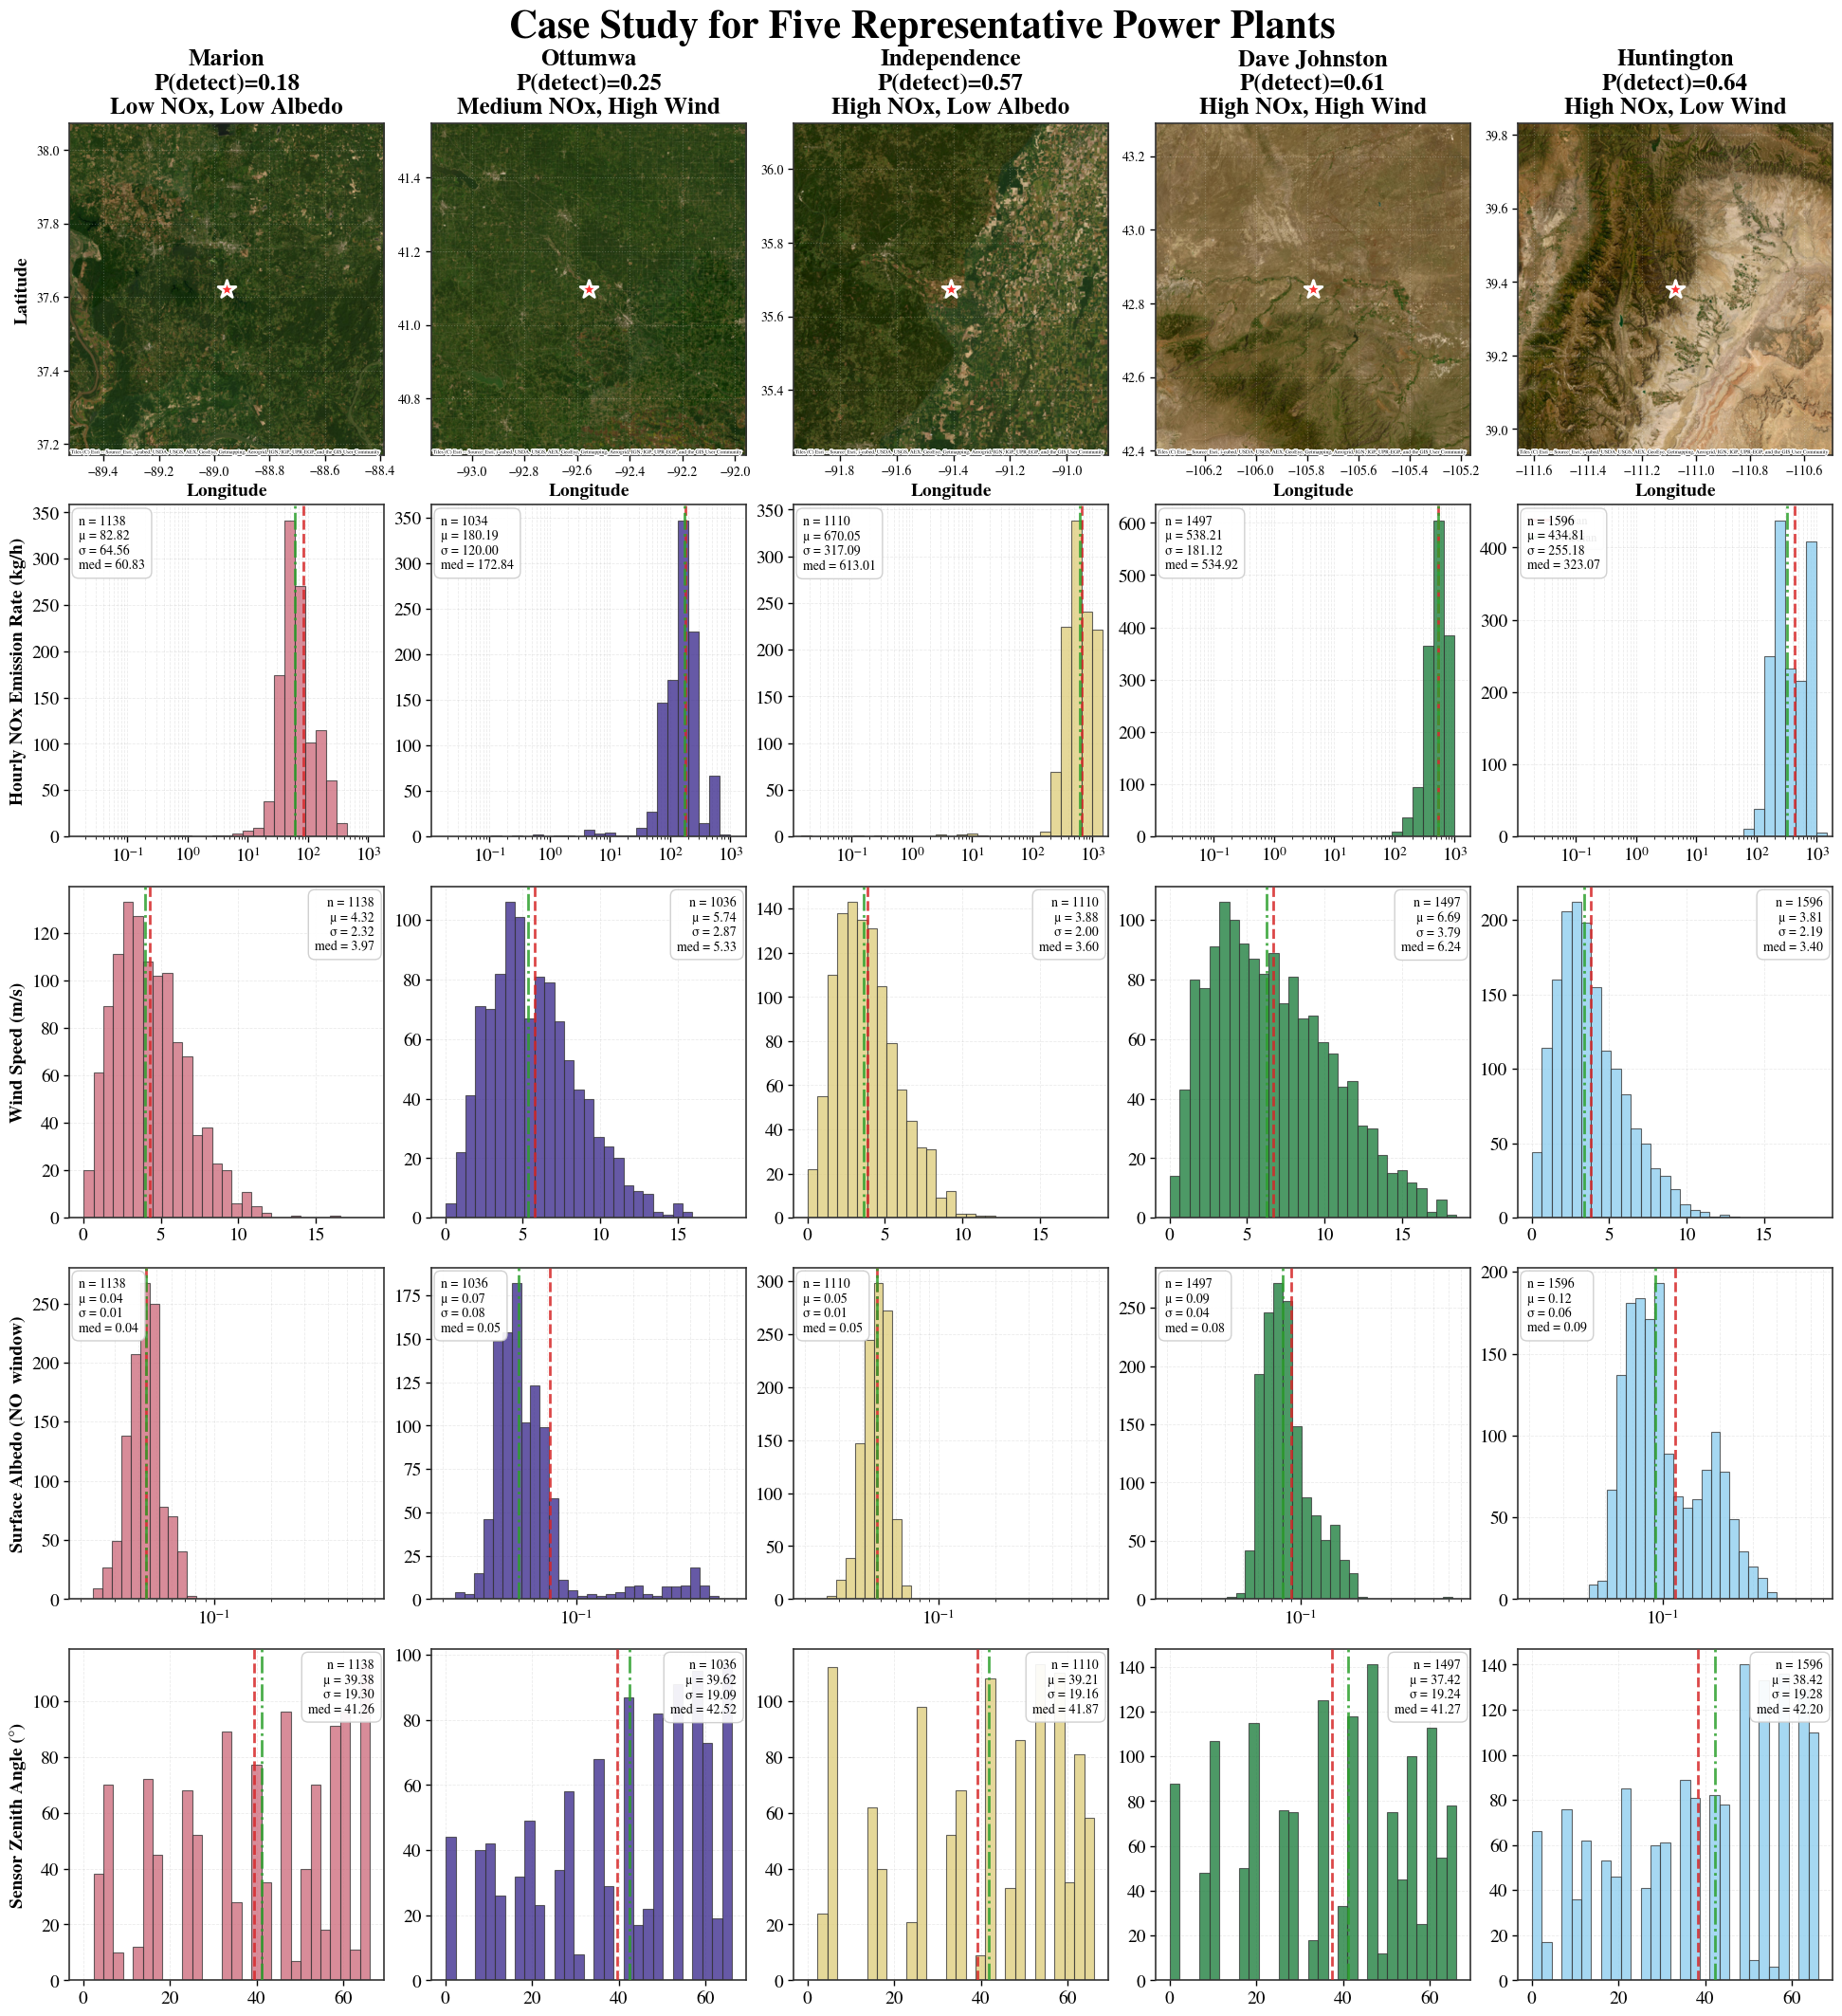

In [4]:
# ─────────────────────────────────────────────────────────────────
# STEP 3: Distribution figure (5 columns × 5 rows)
#   row 0 — satellite imagery, rows 1-4 — variable histograms
# ─────────────────────────────────────────────────────────────────
selected_plants_data = filtered_data[filtered_data['location'].isin(selected_plant_ids)].copy()
selected_plants_data['NOx Mass (kg)'] = selected_plants_data['NOx Mass (lbs)'] * LBS_TO_KG

variables = {
    'NOx Mass (kg)':                          {'label': 'NOx Emission Rate (kg/h)',  'log': True},
    'wind_speed':                             {'label': 'Wind Speed (m/s)',          'log': False},
    'surface_albedo_nitrogendioxide_window':  {'label': 'Surface Albedo (NO₂)',  'log': True},
    'sensor_zenith_angle':                    {'label': 'Sensor Zenith Angle (°)', 'log': False},
}

# Drop rows with NaN in the four plotted variables (necessary for histograms)
n_before = len(selected_plants_data)
selected_plants_data = selected_plants_data.dropna(subset=list(variables.keys()))
print(f'NaN drop on plotted vars: {n_before:,} -> {len(selected_plants_data):,}')

# P(detection) per plant — recompute on the dropna'd subset
plant_detection_prob = (selected_plants_data.groupby('location')['plume_label']
                        .mean().to_dict())

# Manual driver labels (subjective — edit per row inspection)
plant_driver_analysis = {
    selected_plant_ids[0]: ['Low NOx',   'Low Albedo'],
    selected_plant_ids[1]: ['Medium NOx','High Wind'],
    selected_plant_ids[2]: ['High NOx',  'Low Albedo'],
    selected_plant_ids[3]: ['High NOx',  'High Wind'],
    selected_plant_ids[4]: ['High NOx',  'Low Wind'],
}

# Global ranges so all 5 columns share consistent x-axes
global_ranges = {}
for v, info in variables.items():
    a = selected_plants_data[v].dropna()
    if info['log']: a = a[a > 0]
    global_ranges[v] = (a.min(), a.max())

fig = plt.figure(figsize=(20, 22))
gs = fig.add_gridspec(5, 5, hspace=0.15, wspace=0.15,
                      left=0.05, right=0.98, top=0.93, bottom=0.04)

# Row 0: satellite basemaps
print('Creating satellite imagery row ...')
for col, pid in enumerate(selected_plant_ids):
    ax = fig.add_subplot(gs[0, col])
    p = plant_avg_emissions[plant_avg_emissions.location == pid].iloc[0]
    pl_lat, pl_lon = p['lat'], p['lon']
    zoom_km = 50
    dlat = zoom_km / 111.0
    dlon = zoom_km / (111.0 * max(np.cos(np.radians(pl_lat)), 1e-9))
    ax.set_xlim(pl_lon - dlon, pl_lon + dlon)
    ax.set_ylim(pl_lat - dlat, pl_lat + dlat)
    try:
        ctx.add_basemap(ax, crs='EPSG:4326',
                        source=ctx.providers.Esri.WorldImagery,
                        zoom='auto', attribution_size=4)
        ax.scatter(pl_lon, pl_lat, marker='*', s=200, color='#FF3333',
                   edgecolor='white', linewidth=2, zorder=10)
        name = plant_labels[pid].split(': ', 1)[-1]
        prob = plant_detection_prob.get(pid)
        drvs = ', '.join(plant_driver_analysis[pid][:2])
        title = f'{name}\nP(detect)={prob:.2f}\n{drvs}' if prob is not None else f'{name}\n{drvs}'
        ax.set_title(title, fontsize=18, fontweight='bold', pad=8)
        ax.grid(True, alpha=0.2, linestyle=':', linewidth=0.8, color='white')
        ax.tick_params(labelsize=10)
        if col == 0: ax.set_ylabel('Latitude',  fontsize=14, fontweight='bold')
        ax.set_xlabel('Longitude', fontsize=14, fontweight='bold')
    except Exception as e:
        ax.text(0.5, 0.5, 'Satellite Image\nUnavailable',
                ha='center', va='center', transform=ax.transAxes,
                fontsize=14, color='#CC0000', weight='bold')

# Rows 1-4: variable histograms
print('Creating distribution rows ...')
row_labels = [
    'Hourly NOx Emission Rate (kg/h)',
    'Wind Speed (m/s)',
    'Surface Albedo (NO₂ window)',
    'Sensor Zenith Angle (°)',
]
for row, (var, info) in enumerate(variables.items(), start=1):
    gmin, gmax = global_ranges[var]
    bins = (np.logspace(np.log10(gmin), np.log10(gmax), 30) if info['log']
            else np.linspace(gmin, gmax, 30))
    for col, pid in enumerate(selected_plant_ids):
        ax = fig.add_subplot(gs[row, col])
        d = selected_plants_data[selected_plants_data.location == pid][var].dropna()
        if info['log']: d = d[d > 0]
        ax.hist(d, bins=bins, alpha=0.75, color=COLORS_5[col],
                edgecolor='#333333', linewidth=0.8, rasterized=True)
        if info['log']: ax.set_xscale('log')
        if info['log']:
            ax.set_xlim(gmin * 0.75, gmax * 1.25)
        else:
            m = (gmax - gmin) * 0.05
            ax.set_xlim(gmin - m, gmax + m)
        if len(d):
            ax.axvline(d.mean(),   color='#D62728', linestyle='--', linewidth=2.0, alpha=0.85, zorder=5)
            ax.axvline(d.median(), color='#2CA02C', linestyle='-.', linewidth=2.0, alpha=0.85, zorder=5)
        if col == 0:
            ax.set_ylabel(row_labels[row - 1], fontsize=14, fontweight='bold')
        ax.grid(True, alpha=0.25, which='both', linestyle='--', linewidth=0.6)
        ax.set_axisbelow(True)
        if len(d):
            stats_text = (f'n = {len(d)}\n'
                          f'\u03bc = {d.mean():.2f}\n'
                          f'\u03c3 = {d.std():.2f}\n'
                          f'med = {d.median():.2f}')
            xpos, ypos, ha = (0.03, 0.97, 'left') if row in (1, 3) else (0.97, 0.97, 'right')
            ax.text(xpos, ypos, stats_text, transform=ax.transAxes,
                    fontsize=10, va='top', ha=ha,
                    bbox=dict(boxstyle='round,pad=0.5', facecolor='white',
                              edgecolor='#CCCCCC', alpha=0.92, linewidth=1.0),
                    fontproperties=prop, zorder=10)
        if row == 1 and col == 4:
            ax.legend(handles=[
                Line2D([0], [0], color='#D62728', linestyle='--', linewidth=2.0, label='Mean'),
                Line2D([0], [0], color='#2CA02C', linestyle='-.', linewidth=2.0, label='Median'),
            ], loc='upper left', fontsize=9, framealpha=0.92, edgecolor='#CCCCCC')

fig.suptitle('Case Study for Five Representative Power Plants',
             fontsize=30, fontweight='bold', y=0.985)

out_pdf = os.path.join(OUTPUT_DIR, 'selected_5_plants_variable_distributions.pdf')
plt.savefig(out_pdf, bbox_inches='tight', facecolor='white')
print(f'\n\u2713 Saved: {out_pdf}')
plt.show()
